# PhysioNet Fractionwise KL Divergence Plotting

This notebook loads the aggregated PhysioNet results and plots fractionwise KL divergence values comparing MCal_CE vs MCal_CE_Uncond.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path

# Use default matplotlib color cycle (blue/orange)
matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=['#1f77b4', '#ff7f0e'])
matplotlib.rcParams['mathtext.fontset'] = 'cm'

# Figure dimensions
fig_width = 3.25  # inches per plot
fig_height = 2.4  # inches per plot

# Shared font/style settings
LABEL_FONTSIZE = 14
TICK_LABELSIZE = 12
LEGEND_FONTSIZE = 12
LINEWIDTH = 2.5
BAND_ALPHA = 0.25
GRID_ALPHA = 0.2
TIGHT_PAD = 0.5

## Load PhysioNet Results Data

In [2]:
# Load the aggregated results JSON file
# Use relative path from notebook location (experiments/tabular/)
results_path = Path("./results/json/aggregated_results_physionet.json")

# Check if file exists
if not results_path.exists():
    print(f"❌ Results file not found at: {results_path.absolute()}")
    print("Please run the PhysioNet benchmark first to generate results.")
    print("Command: python physionet_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
    results = None
else:
    print(f"✅ Loading results from: {results_path.absolute()}")
    
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    print(f"Available methods: {list(results.keys())}")

✅ Loading results from: /ssd1/ayx98/MCal/experiments/tabular/results/json/aggregated_results_physionet.json
Available methods: ['baseline', 'replace', 'archmod', 'retrain', 'mcal_ce', 'platt', 'temperature', 'mcal_ce_uncond']


In [3]:
# Check if both mcal_ce and mcal_ce_uncond methods exist in results
methods_to_compare = ['mcal_ce', 'mcal_ce_uncond']
missing_methods = [method for method in methods_to_compare if method not in results]

if missing_methods:
    print(f"❌ Missing methods: {missing_methods}")
    print(f"Available methods: {list(results.keys())}")
    print("Please run the PhysioNet benchmark with both mcal_ce and mcal_ce_uncond methods first.")
    print("Command: python physionet_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print("✅ Both mcal_ce and mcal_ce_uncond methods found!")
    
    # Extract fractionwise data for both methods
    methods_data = {}
    
    for method in methods_to_compare:
        method_results = results[method]
        
        if 'fraction_wise_results_transformed' in method_results:
            fraction_data = method_results['fraction_wise_results_transformed']
            
            methods_data[method] = {
                'mean_argmax': np.array(fraction_data['mean_argmax']),
                'std_argmax': np.array(fraction_data['std_argmax'])
            }
            
            print(f"✅ {method} fractionwise data loaded successfully")
        else:
            print(f"❌ Fractionwise results not found for {method}")
            print(f"Available keys: {list(method_results.keys())}")
    
    # Create fraction labels if we have data
    if methods_data:
        # Use the first method to determine number of fractions
        first_method = list(methods_data.keys())[0]
        n_fractions = len(methods_data[first_method]['mean_argmax'])
        fractions = np.arange(n_fractions) / 10  # PhysioNet typically uses 10 fractions
        fraction_labels = [f"{i}/10" for i in range(n_fractions)]
        
        print(f"Number of fractions: {n_fractions}")
        print(f"Fraction range: 0/10 to {n_fractions-1}/10")
        # pdb.set_trace()
        
        # Print summary for both methods
        for method in methods_to_compare:
            if method in methods_data:
                data = methods_data[method]
                print(f"\n{method.upper()} SUMMARY:")
                print(f"   Mean KL (argmax) range: {data['mean_argmax'].min():.6f} to {data['mean_argmax'].max():.6f}")

✅ Both mcal_ce and mcal_ce_uncond methods found!
✅ mcal_ce fractionwise data loaded successfully
✅ mcal_ce_uncond fractionwise data loaded successfully
Number of fractions: 10
Fraction range: 0/10 to 9/10

MCAL_CE SUMMARY:
   Mean KL (argmax) range: 0.000002 to 0.034932

MCAL_CE_UNCOND SUMMARY:
   Mean KL (argmax) range: 0.000126 to 0.456100


In [4]:
methods_data

{'mcal_ce': {'mean_argmax': array([2.05973629e-06, 4.30277064e-03, 1.20631557e-02, 1.30878042e-02,
         5.96848177e-03, 5.80432561e-03, 3.94902946e-03, 1.02711599e-02,
         1.57144289e-02, 3.49315353e-02]),
  'std_argmax': array([0.        , 0.00168392, 0.00460918, 0.00979131, 0.00422543,
         0.00404583, 0.00231174, 0.00882353, 0.00930372, 0.01236239])},
 'mcal_ce_uncond': {'mean_argmax': array([1.18932389e-03, 1.26251683e-04, 3.93196959e-03, 1.51306413e-02,
         3.57146010e-02, 7.30375618e-02, 1.19041578e-01, 1.99620555e-01,
         3.09804136e-01, 4.56099641e-01]),
  'std_argmax': array([0.00028111, 0.00012221, 0.00171494, 0.00521952, 0.00567884,
         0.01469196, 0.016944  , 0.01647638, 0.01758315, 0.02106228])}}

## Plot MCal_CE vs MCal_CE_Uncond Fractionwise KL Divergence (Argmax Only)

In [5]:
methods_data

{'mcal_ce': {'mean_argmax': array([2.05973629e-06, 4.30277064e-03, 1.20631557e-02, 1.30878042e-02,
         5.96848177e-03, 5.80432561e-03, 3.94902946e-03, 1.02711599e-02,
         1.57144289e-02, 3.49315353e-02]),
  'std_argmax': array([0.        , 0.00168392, 0.00460918, 0.00979131, 0.00422543,
         0.00404583, 0.00231174, 0.00882353, 0.00930372, 0.01236239])},
 'mcal_ce_uncond': {'mean_argmax': array([1.18932389e-03, 1.26251683e-04, 3.93196959e-03, 1.51306413e-02,
         3.57146010e-02, 7.30375618e-02, 1.19041578e-01, 1.99620555e-01,
         3.09804136e-01, 4.56099641e-01]),
  'std_argmax': array([0.00028111, 0.00012221, 0.00171494, 0.00521952, 0.00567884,
         0.01469196, 0.016944  , 0.01647638, 0.01758315, 0.02106228])}}

Saving plots to: /ssd1/ayx98/MCal/experiments/tabular/figures


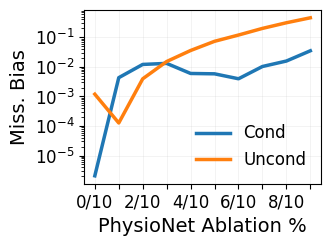

Saved: /ssd1/ayx98/MCal/experiments/tabular/figures/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf

✅ PhysioNet MCal comparison log plot saved to /ssd1/ayx98/MCal/experiments/tabular/figures/


In [6]:
# Create comparison plot for MCal_CE vs MCal_CE_Uncond with log scale (Argmax only)
if 'methods_data' in locals() and len(methods_data) >= 2:
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    print(f"Saving plots to: {abs_output_dir}")
    
    # Get data for both methods
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Plot: KL Divergence (Argmax/One-hot) Comparison - LOG SCALE
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    
    # MCal_CE line
    ax.plot(fractions, mcal_ce_data['mean_argmax'], '-', 
            label='Cond', linewidth=LINEWIDTH, color='#1f77b4')
    # ax.fill_between(fractions, 
    #                 mcal_ce_data['mean_argmax'] - 0.5*mcal_ce_data['std_argmax'], 
    #                 mcal_ce_data['mean_argmax'] + 0.5*mcal_ce_data['std_argmax'],
    #                 alpha=BAND_ALPHA, color='#1f77b4')
    
    # MCal_CE_Uncond line
    ax.plot(fractions, mcal_ce_uncond_data['mean_argmax'], '-', 
            label='Uncond', linewidth=LINEWIDTH, color='#ff7f0e')
    # ax.fill_between(fractions, 
    #                 mcal_ce_uncond_data['mean_argmax'] - 0.5*mcal_ce_uncond_data['std_argmax'], 
    #                 mcal_ce_uncond_data['mean_argmax'] + 0.5*mcal_ce_uncond_data['std_argmax'],
    #                 alpha=BAND_ALPHA, color='#ff7f0e')
    
    ax.set_xlabel('PhysioNet Ablation %', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
    ax.set_yscale('log')  # LOG SCALE
    ax.legend(fontsize=LEGEND_FONTSIZE, loc='lower right', frameon=False)
    ax.grid(True, alpha=GRID_ALPHA, linewidth=0.5)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    
    # Set x-axis ticks - show every other label to avoid clutter
    ax.set_xticks(fractions)
    display_labels = [label if i % 2 == 0 else '' for i, label in enumerate(fraction_labels)]
    ax.set_xticklabels(display_labels)
    
    plt.tight_layout(pad=TIGHT_PAD)
    plt.savefig(f'{output_dir}/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf', dpi=300)
    plt.show()
    print(f"Saved: {abs_output_dir}/physionet_mcal_comparison_fractionwise_kl_argmax_log.pdf")
    
    print(f"\n✅ PhysioNet MCal comparison log plot saved to {abs_output_dir}/")
    
else:
    print("❌ No comparison data available to plot")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

✅ mcal_ce accuracy data loaded
✅ mcal_ce_uncond accuracy data loaded
✅ baseline accuracy data loaded


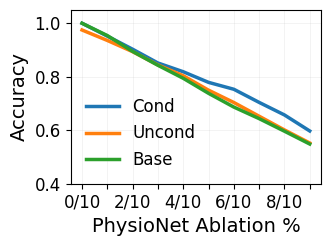

Saved: /ssd1/ayx98/MCal/experiments/tabular/figures/physionet_accuracy_comparison_with_baseline.pdf

✅ PhysioNet accuracy comparison plot saved to /ssd1/ayx98/MCal/experiments/tabular/figures/


In [7]:
# Plot Accuracy Comparison between Methods (mcal_ce, mcal_ce_uncond, baseline only)
if 'results' in locals():
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    
    # Only plot these three methods
    methods_to_plot = ['mcal_ce', 'mcal_ce_uncond', 'baseline']
    colors = {'mcal_ce': '#1f77b4', 'mcal_ce_uncond': '#ff7f0e', 'baseline': '#2ca02c'}
    labels = {'mcal_ce': 'Cond', 'mcal_ce_uncond': 'Uncond', 'baseline': 'Base'}
    
    # Extract accuracy data for the three methods
    accuracy_data = {}
    
    for method in methods_to_plot:
        if method not in results:
            print(f"❌ {method} not found in results")
            continue
        result = results[method]
        if method == 'baseline':
            if 'fraction_wise_results' in result and 'mean_accuracy' in result['fraction_wise_results']:
                accuracy_data[method] = {
                    'mean_accuracy': np.array(result['fraction_wise_results']['mean_accuracy']),
                    'std_accuracy': np.array(result['fraction_wise_results']['std_accuracy'])
                }
                print(f"✅ {method} accuracy data loaded")
        else:
            if 'fraction_wise_results_transformed' in result and 'mean_accuracy' in result['fraction_wise_results_transformed']:
                accuracy_data[method] = {
                    'mean_accuracy': np.array(result['fraction_wise_results_transformed']['mean_accuracy']),
                    'std_accuracy': np.array(result['fraction_wise_results_transformed']['std_accuracy'])
                }
                print(f"✅ {method} accuracy data loaded")
    
    if accuracy_data:
        # Create accuracy comparison plot
        fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
        
        for method in methods_to_plot:
            if method not in accuracy_data:
                continue
            data = accuracy_data[method]
            color = colors[method]
            label = labels[method]
            
            ax.plot(fractions, data['mean_accuracy'], '-', 
                   label=label, linewidth=LINEWIDTH, color=color)
            # ax.fill_between(fractions, 
            #                data['mean_accuracy'] - 0.5*data['std_accuracy'], 
            #                data['mean_accuracy'] + 0.5*data['std_accuracy'],
            #                alpha=BAND_ALPHA, color=color)
        
        ax.set_xlabel('PhysioNet Ablation %', fontsize=LABEL_FONTSIZE)
        ax.set_ylabel('Accuracy', fontsize=LABEL_FONTSIZE)
        ax.set_ylim(0.4, 1.05)
        ax.legend(fontsize=LEGEND_FONTSIZE, loc='best', frameon=False)
        ax.grid(True, alpha=GRID_ALPHA, linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
        
        # Set x-axis ticks - show every other label to avoid clutter
        ax.set_xticks(fractions)
        display_labels = [label if i % 2 == 0 else '' for i, label in enumerate(fraction_labels)]
        ax.set_xticklabels(display_labels)
        
        plt.tight_layout(pad=TIGHT_PAD)
        plt.savefig(f'{output_dir}/physionet_accuracy_comparison_with_baseline.pdf', dpi=300)
        plt.show()
        print(f"Saved: {abs_output_dir}/physionet_accuracy_comparison_with_baseline.pdf")
        
        print(f"\n✅ PhysioNet accuracy comparison plot saved to {abs_output_dir}/")
    else:
        print("❌ No accuracy data found for any methods")
else:
    print("❌ No results data loaded")

## Plot MCal_CE vs MCal_CE_Uncond Fractionwise Accuracy Comparison

## MCal_CE vs MCal_CE_Uncond Comparison Statistics

In [8]:
# Detailed comparison statistics between MCal_CE and MCal_CE_Uncond
if 'methods_data' in locals() and len(methods_data) >= 2:
    print("📊 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON")
    print("=" * 80)
    
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Argmax KL Divergence Comparison
    print(f"\n🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:")
    print(f"{'Method':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12}")
    print("-" * 70)
    print(f"{'MCal_CE':<20} {mcal_ce_data['mean_argmax'].min():<12.6f} {mcal_ce_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_data['mean_argmax'].mean():<12.6f} {mcal_ce_data['mean_argmax'].std():<12.6f}")
    print(f"{'MCal_CE_Uncond':<20} {mcal_ce_uncond_data['mean_argmax'].min():<12.6f} {mcal_ce_uncond_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_uncond_data['mean_argmax'].mean():<12.6f} {mcal_ce_uncond_data['mean_argmax'].std():<12.6f}")
    
    # Calculate improvement
    argmax_improvement = ((mcal_ce_data['mean_argmax'].mean() - mcal_ce_uncond_data['mean_argmax'].mean()) 
                         / mcal_ce_data['mean_argmax'].mean()) * 100
    print(f"\n   → MCal_CE_Uncond vs MCal_CE improvement: {argmax_improvement:+.2f}%")
    
    # Fraction-wise comparison - show largest differences
    print(f"\n📈 FRACTION-WISE ANALYSIS:")
    argmax_diff = mcal_ce_data['mean_argmax'] - mcal_ce_uncond_data['mean_argmax']
    
    # Find fractions with largest improvements for MCal_CE_Uncond
    best_argmax_fraction = np.argmax(argmax_diff)  # Largest positive difference (MCal_CE higher)
    
    print(f"   Largest MCal_CE_Uncond advantage (Argmax): Fraction {best_argmax_fraction}/{n_fractions}")
    print(f"      MCal_CE: {mcal_ce_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      MCal_CE_Uncond: {mcal_ce_uncond_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      Difference: {argmax_diff[best_argmax_fraction]:.6f}")
    
    # Show trends
    ce_argmax_trend = "increasing" if mcal_ce_data['mean_argmax'][-1] > mcal_ce_data['mean_argmax'][0] else "decreasing"
    uncond_argmax_trend = "increasing" if mcal_ce_uncond_data['mean_argmax'][-1] > mcal_ce_uncond_data['mean_argmax'][0] else "decreasing"
    
    print(f"\n📊 TRENDS ACROSS ABLATION FRACTIONS:")
    print(f"   MCal_CE Argmax KL: {ce_argmax_trend} ({mcal_ce_data['mean_argmax'][0]:.6f} → {mcal_ce_data['mean_argmax'][-1]:.6f})")
    print(f"   MCal_CE_Uncond Argmax KL: {uncond_argmax_trend} ({mcal_ce_uncond_data['mean_argmax'][0]:.6f} → {mcal_ce_uncond_data['mean_argmax'][-1]:.6f})")
    
else:
    print("❌ No comparison data available for detailed statistics")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📊 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON

🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:
Method               Min          Max          Mean         Std         
----------------------------------------------------------------------
MCal_CE              0.000002     0.034932     0.010609     0.009313    
MCal_CE_Uncond       0.000126     0.456100     0.121370     0.147504    

   → MCal_CE_Uncond vs MCal_CE improvement: -1043.97%

📈 FRACTION-WISE ANALYSIS:
   Largest MCal_CE_Uncond advantage (Argmax): Fraction 2/10
      MCal_CE: 0.012063
      MCal_CE_Uncond: 0.003932
      Difference: 0.008131

📊 TRENDS ACROSS ABLATION FRACTIONS:
   MCal_CE Argmax KL: increasing (0.000002 → 0.034932)
   MCal_CE_Uncond Argmax KL: increasing (0.001189 → 0.456100)


## Export Comparison Data

In [9]:
# Export the comparison data in a nice table format
if 'methods_data' in locals() and len(methods_data) >= 2:
    import pandas as pd
    
    # Create comprehensive comparison DataFrame
    comparison_data = []
    
    for i in range(len(fractions)):
        comparison_data.append({
            'Fraction': fraction_labels[i],
            'Ablation_Ratio': fractions[i],
            'MCal_CE_Argmax_Mean': methods_data['mcal_ce']['mean_argmax'][i],
            'MCal_CE_Argmax_Std': methods_data['mcal_ce']['std_argmax'][i],
            'MCal_CE_Uncond_Argmax_Mean': methods_data['mcal_ce_uncond']['mean_argmax'][i],
            'MCal_CE_Uncond_Argmax_Std': methods_data['mcal_ce_uncond']['std_argmax'][i],
            'Argmax_Improvement': ((methods_data['mcal_ce']['mean_argmax'][i] - methods_data['mcal_ce_uncond']['mean_argmax'][i]) / methods_data['mcal_ce']['mean_argmax'][i]) * 100
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("📋 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:")
    print(df_comparison.round(6).to_string(index=False))
    
    # Save to CSV
    csv_path = Path("./results/physionet_mcal_comparison_fractionwise_data.csv")
    df_comparison.to_csv(csv_path, index=False)
    print(f"\n✅ Detailed comparison data saved to: {csv_path}")
    
    # Summary statistics
    print(f"\n📊 SUMMARY STATISTICS:")
    print(f"   Average Argmax improvement: {df_comparison['Argmax_Improvement'].mean():+.2f}%")
    print(f"   Best Argmax improvement: {df_comparison['Argmax_Improvement'].max():+.2f}% (Fraction {df_comparison.loc[df_comparison['Argmax_Improvement'].idxmax(), 'Fraction']})")
    
else:
    print("❌ No comparison data available to export")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📋 PHYSIONET: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:
Fraction  Ablation_Ratio  MCal_CE_Argmax_Mean  MCal_CE_Argmax_Std  MCal_CE_Uncond_Argmax_Mean  MCal_CE_Uncond_Argmax_Std  Argmax_Improvement
    0/10             0.0             0.000002            0.000000                    0.001189                   0.000281       -57641.561069
    1/10             0.1             0.004303            0.001684                    0.000126                   0.000122           97.065805
    2/10             0.2             0.012063            0.004609                    0.003932                   0.001715           67.405133
    3/10             0.3             0.013088            0.009791                    0.015131                   0.005220          -15.608707
    4/10             0.4             0.005968            0.004225                    0.035715                   0.005679         -498.386698
    5/10             0.5             0.005804            0.004046                    0.073038 